<a href="https://colab.research.google.com/github/KarthikRamu-gif/electricity-deman-forecasting/blob/main/notebooks/lstm_divyank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM Forecasting for Electricity Demand

## Individual Project

In this notebook, i will use the LSTM deep learning model to forecast electricity demand using the AEP hourly dataset.

This notebook contains:
- baseline forecasting
- LSTM model implementation
- model training
- forecast evaluation
- final discussion and reflection

The preprocessing steps and train-test split are based on the shared group notebook.

#Importing Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Loading and Preprocessing Dataset

The same preprocessing steps from the shared group notebook are applied before training the LSTM model.

In [2]:
# Load dataset
df = pd.read_csv('AEP_hourly.csv')

# Convert datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set datetime as index
df.set_index('Datetime', inplace=True)

# Sort values
df = df.sort_index()

# Remove duplicate timestamps
df = df[~df.index.duplicated(keep='first')]

# Preview dataset
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


# Train-Test Split

The dataset is divided chronologically into training and testing sets to preserve the time dependency structure of the electricity demand data.

In [3]:
# Train-test split
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Display shapes
print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

Training set shape: (97015, 1)
Testing set shape: (24254, 1)


# Baseline Forecasting Model

A Seasonal Naive forecasting method is used as the baseline model for comparison with the LSTM model.

In [4]:
# Seasonal naive forecast
season_length = 24

baseline_forecast = test['AEP_MW'].shift(season_length)

# Remove missing values
baseline_forecast = baseline_forecast.dropna()

# Align actual values
actual_values = test['AEP_MW'][season_length:]

# Baseline Model Evaluation

In [5]:
# Calculate MAE
baseline_mae = mean_absolute_error(actual_values, baseline_forecast)

# Calculate RMSE
baseline_rmse = np.sqrt(mean_squared_error(actual_values, baseline_forecast))

# Display results
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 921.3749071399092
Baseline RMSE: 1221.321825281103


### Baseline Model Results

The Seasonal Naive model achieved relatively low forecasting errors.

This suggests that the electricity demand data contains strong repeating seasonal patterns, making the baseline model effective for short-term forecasting.

# Data Scaling for LSTM

LSTM models perform better when the data is normalized into a smaller numerical range.

In [6]:
# Initialize scaler
scaler = MinMaxScaler()

# Scale training data
train_scaled = scaler.fit_transform(train)

# Scale testing data
test_scaled = scaler.transform(test)

# Creating Input Sequences

The LSTM model uses previous observations to predict future electricity demand values.

In [7]:
# Function to create sequences
def create_sequences(data, sequence_length):

    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

# Sequence length
sequence_length = 24

# Create sequences
X_train, y_train = create_sequences(train_scaled, sequence_length)

X_test, y_test = create_sequences(test_scaled, sequence_length)

# Display shapes
print(X_train.shape)
print(X_test.shape)

(96991, 24, 1)
(24230, 24, 1)


# Building the LSTM Model

The LSTM model is used to learn temporal patterns and dependencies in electricity demand data.

In [8]:
# Build LSTM model
model = Sequential()

model.add(
    LSTM(
        50,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dense(1))

# Compile model
model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

# Training the LSTM Model

In [9]:
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 0.0026 - val_loss: 3.3829e-04
Epoch 2/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 4.5830e-04 - val_loss: 2.7254e-04
Epoch 3/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 3.7465e-04 - val_loss: 2.4318e-04
Epoch 4/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - loss: 3.3231e-04 - val_loss: 2.1726e-04
Epoch 5/5
3031/3031 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 3.1069e-04 - val_loss: 2.5327e-04


# Generating Forecasts Using LSTM

In [10]:
# Generate predictions
predictions = model.predict(X_test)

# Reverse scaling
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

758/758 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


# LSTM Model Evaluation

In [11]:
# Calculate MAE
lstm_mae = mean_absolute_error(
    y_test_actual,
    predictions
)

# Calculate RMSE
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

# Display results
print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE: 205.12662686526258
LSTM RMSE: 255.15675027555022


###LSTM Model Results

The forecasting accuracy of LSTM model was significantly better than that of the baseline forecasting method, in terms of the smaller MAE and RMSE.

This indicates that the LSTM model successfully captured the electricity demand data's temporal patterns and dependencies to a greater extent.

This result suggests that Deep Learning techniques can yield a good forecasting capability for time series data exhibiting recurrent seasonal and nonlinear behaviour.

# Forecast Visualization

The following plot compares the actual electricity demand values with the LSTM forecasted values.

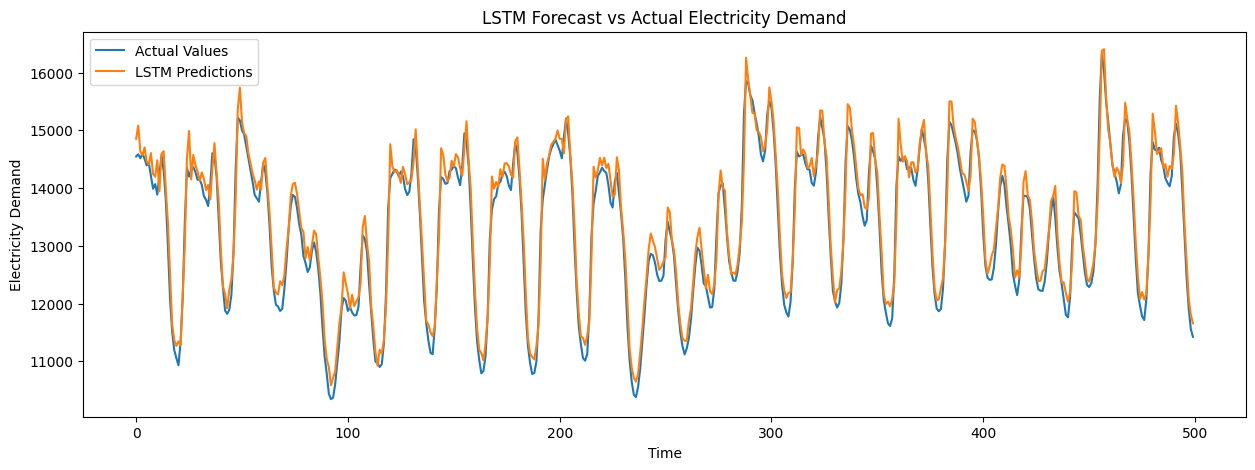

In [12]:
# Plot actual vs predicted values
plt.figure(figsize=(15,5))

plt.plot(
    y_test_actual[:500],
    label='Actual Values'
)

plt.plot(
    predictions[:500],
    label='LSTM Predictions'
)

plt.title('LSTM Forecast vs Actual Electricity Demand')
plt.xlabel('Time')
plt.ylabel('Electricity Demand')

plt.legend()

# Save figure
plt.savefig('lstm_forecast.png')

plt.show()

###Forecast Visualization Interpretation

The electricity demand values predicted by the LSTM model were very close to the actual values throughout the forecasting period.

The model was capable of forecasting the seasonal pattern and short-term fluctuations well and had a lower forecasting error than the baseline and SARIMA model.

From the visualization, it can be seen that the LSTM model has performed well in predicting electricity demand data.

# Comparison Between Baseline and LSTM

In [13]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['Baseline', 'LSTM'],
    'MAE': [baseline_mae, lstm_mae],
    'RMSE': [baseline_rmse, lstm_rmse]
})

comparison

,Model,MAE,RMSE
0,Baseline,921.374907,1221.321825
1,LSTM,205.126627,255.156750


#Discussion

The LSTM model has strongly outperformed the baseline model, which is based on Seasonal Naive, in terms of both MAE and RMSE.

The model was able to learn complex temporal relationships and repeating seasonal patterns present in the electricity demand data.

The LSTM model outperformed the traditional statistical models in predicting the dataset, especially when dealing with nonlinear patterns and short-term variations.

A drawback of the model is the increased training time and computing expenses of the deep learning methods.

#Conclusion and Reflection

Here, a deep learning model using LSTM networks was designed and tested for prediction of electric load.

The model was found to be a good performer in terms of forecasting errors as compared to the baseline method.

The project showcased the ability of deep learning models to learn temporal dependencies and seasonal patterns from time series data.

One of the main challenges in the project was to process and store massive amounts of sequential data and generate sequences for use in the LSTM model.

The overall results indicate that LSTM models can be used to make high precision predictions for electricity demand prediction tasks.